In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet('green_tripdata_2021-01.parquet')

print(df.columns)
df.head()

Index(['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge',
       'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge'],
      dtype='object')


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00


In [24]:
# Filter for reasonable values
df = df[(df.trip_distance > 0) & (df.trip_distance < 50)]
df = df[(df.fare_amount > 0) & (df.fare_amount < 200)]
df = df.dropna(subset=['passenger_count']) # Remove missing values

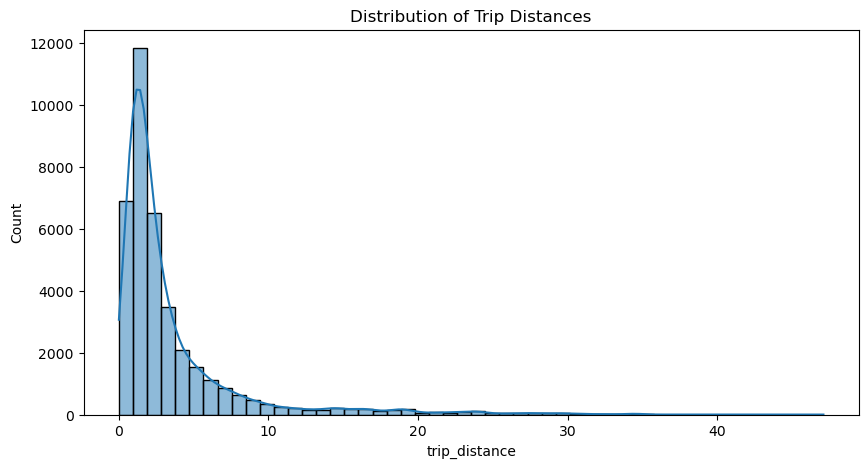

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(df.trip_distance, bins=50, kde=True)
plt.title('Distribution of Trip Distances')
plt.show()

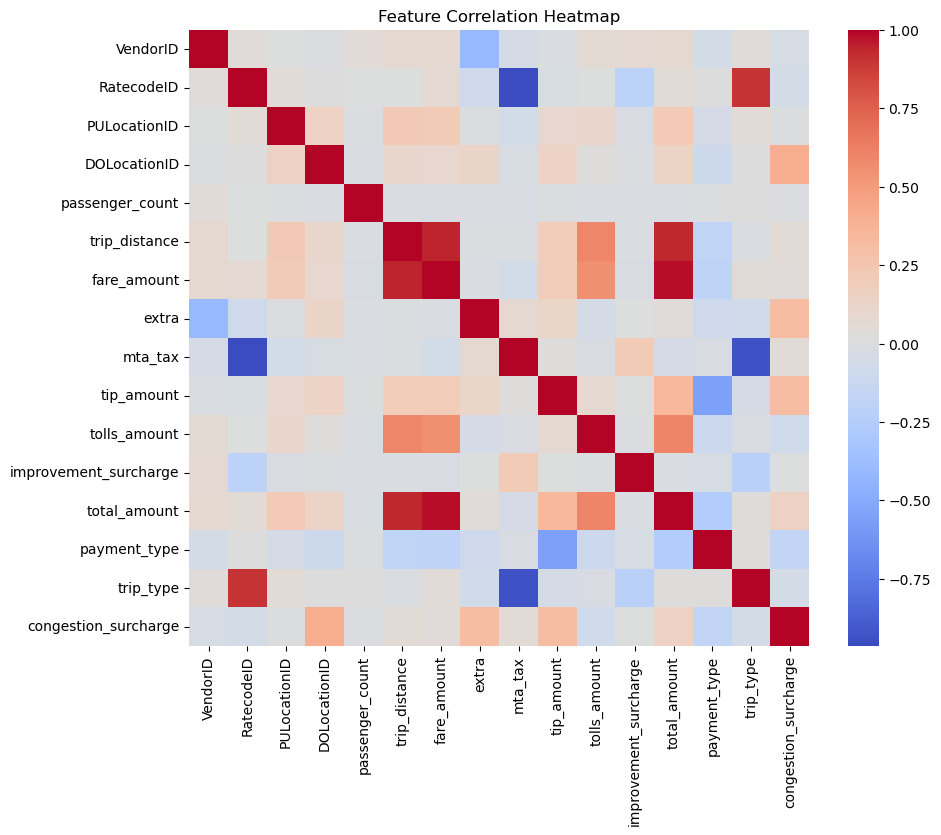

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [40]:
# Choose 3 features for now
features = ['trip_distance', 'passenger_count', 'congestion_surcharge', 'fare_amount']
X = df[features]

# Targets
y_clf = (df['tip_amount'] > 0).astype(int) # For Classification (1 if tipped, 0 if not)

In [41]:
from sklearn.model_selection import train_test_split

# Split for Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

In [44]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

# Train the model
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train_clf, y_train_clf)

# Evaluate performance
y_pred_clf = clf_model.predict(X_test_clf)
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf)}")
print(classification_report(y_test_clf, y_pred_clf))

cv_scores = cross_val_score(clf_model, X, y_clf, cv=5, scoring='accuracy')

print(f"Scores for each fold: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

#sklearn has a good classification report with precision, reccall, f1-score, accuracy and averages, which give a good overview and gives dimensions to whether a model is good or has problems on one side or another
#my 3-feature model is bad, its a coin flip basically. I added a fourth feature and it didnt change much.
#By using cross_val_score, you ensure the model's performance isn't a fluke from one "lucky" train/test split. Low standard deviation further proves this.

#Feature Timing: I only used features that are known at the moment of pickup (like trip_distance and passenger_count).

#I excluded "Future" Data: To avoid leakage, i did not include features like total_amount or tolls_amount. Including those would result in high accuracy but would be "cheating" because that information is only finalized after the tip is decided.

Accuracy: 0.5582093448185852
              precision    recall  f1-score   support

           0       0.56      0.59      0.57      3847
           1       0.56      0.52      0.54      3815

    accuracy                           0.56      7662
   macro avg       0.56      0.56      0.56      7662
weighted avg       0.56      0.56      0.56      7662

Scores for each fold: [0.55311929 0.56382146 0.5586738  0.54966715 0.54301005]
Mean Accuracy: 0.5537
Standard Deviation: 0.0072


In [37]:
joblib.dump(clf_model, 'classification_model.pkl')

['classification_model.pkl']